# Energy Reconstruction Using CNN

In [3]:
import numpy as np
import tensorflow as tf
import os
import matplotlib.pyplot as plt
import pandas as pd

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten

from tensorflow.keras.callbacks import ModelCheckpoint

from data_tools import load_preprocessed, dataPrep, nameModel

## FIX THIS!
simPrefix = os.getcwd()+'\\simdata'

## Data Input

In [4]:
x, y = load_preprocessed(simPrefix, 'train')

Percentage of events with a NaN: 2.68


In [3]:
print(x.shape)
print(y.keys())
# each station has 2 tanks, each tank has 2 DOMs (high/log gain)
# each tank measures charge and time
# each station gives 2 charges and 2 times, 4 pieces of data
# x: (num, i, j, data)
# charge measured in VEM, vertical equivalent muon

# 'dir' is true direction, rest of dir are reconstructed by simulations
# plane assumes shower is flat plane
# laputop performs likelihood analysis
# small compromises between

(549773, 10, 10, 4)
dict_keys(['comp', 'energy', 'dir', 'plane_dir', 'laputop_dir', 'small_dir'])


In [5]:
# 85/15 split for training/testing
energy = y['energy']
comp = y['comp']
theta, phi = y['dir'].transpose().astype('float64')
th,ph = y['plane_dir'].transpose().astype('float64')
nevents = len(energy)
randSel = np.random.uniform(size=nevents)
trainCut = randSel < 0.85
valCut = np.logical_not(trainCut)
energy.shape

(549773,)

(54977300,)


(array([5.493000e+04, 9.872150e+05, 1.290617e+06, 1.038011e+06,
        8.632230e+05, 8.052650e+05, 8.822760e+05, 8.311710e+05,
        6.820680e+05, 5.395110e+05, 4.318090e+05, 3.568630e+05,
        3.025000e+05, 2.587980e+05, 2.215320e+05, 1.924280e+05,
        1.675230e+05, 1.472540e+05, 1.284860e+05, 1.139070e+05,
        1.014040e+05, 9.167500e+04, 8.395600e+04, 7.559700e+04,
        6.995800e+04, 6.322200e+04, 5.594300e+04, 4.924500e+04,
        4.287600e+04, 3.836300e+04, 3.620600e+04, 3.380800e+04,
        3.102600e+04, 2.809400e+04, 2.567900e+04, 2.294000e+04,
        2.117300e+04, 1.946800e+04, 1.789000e+04, 1.651800e+04,
        1.506900e+04, 1.373700e+04, 1.261200e+04, 1.144700e+04,
        1.055500e+04, 9.355000e+03, 8.511000e+03, 7.710000e+03,
        6.929000e+03, 6.343000e+03, 5.529000e+03, 4.802000e+03,
        3.893000e+03, 2.670000e+03, 1.770000e+03, 1.324000e+03,
        1.067000e+03, 1.094000e+03, 1.140000e+03, 1.234000e+03,
        1.314000e+03, 1.426000e+03, 1.64

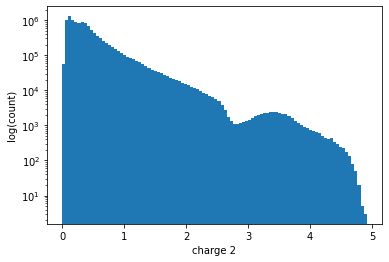

In [11]:
x.shape
x1 = x[...,1].reshape(-1)
print(x1.shape)
plt.xlabel('charge 2')
plt.ylabel('log(count)')
plt.hist(x1[x1!=0],bins=100,log=True)

In [18]:
x.shape
x1 = x[...,0].reshape(-1)
x2 = x[...,1].reshape(-1)
cut = logical_and(x1 != 0,x2 != 0)
x1 = x1[cut]
x2 = x2[cut]
plt.xlabel('charge 1')
plt.ylabel('log(count)')
plt.hist(x1,bins=100,log=True)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [15]:
np.count_nonzero((x1-x2)<0.1)

ValueError: operands could not be broadcast together with shapes (11256037,) (11390203,) 

(array([1159., 1668., 1657., 1869., 1510., 2169., 2170., 2576., 2817.,
        2800., 3437., 3511., 3561., 3814., 4023., 4084., 4664., 4537.,
        5245., 5773., 5689., 6360., 6045., 6500., 6895., 6632., 6857.,
        7011., 7299., 7394., 7506., 7445., 8071., 7859., 7693., 7689.,
        8320., 7949., 8067., 8361., 8880., 9034., 8353., 8727., 8827.,
        8721., 9170., 7949., 8734., 8152., 8596., 9080., 8223., 8409.,
        8677., 8211., 8918., 8641., 7572., 7459., 7879., 7831., 8007.,
        7416., 6411., 6859., 7031., 5893., 6818., 6302., 6204., 6175.,
        5958., 5470., 5395., 4975., 5476., 5214., 4598., 5208., 5141.,
        4510., 3203., 3626., 3761., 3382., 3176., 2712., 2345., 2291.,
        2477., 1518., 1588., 1499., 1217., 1147.,  868.,  704.,  332.,
         137.]),
 array([2.00752512, 2.01883448, 2.03014384, 2.0414532 , 2.05276257,
        2.06407193, 2.07538129, 2.08669065, 2.09800001, 2.10930938,
        2.12061874, 2.1319281 , 2.14323746, 2.15454682, 2.16585618

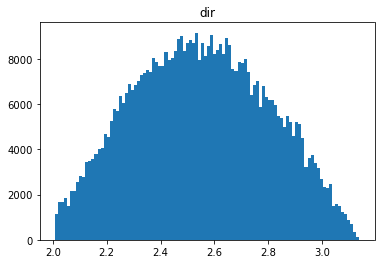

In [6]:
plt.title('dir')
plt.hist(theta,bins=100)

(array([2.0000e+00, 3.0000e+00, 8.0000e+00, 1.0000e+01, 1.1000e+01,
        1.8000e+01, 2.0000e+01, 2.2000e+01, 2.9000e+01, 2.1000e+01,
        2.5000e+01, 3.9000e+01, 3.4000e+01, 4.3000e+01, 4.9000e+01,
        5.2000e+01, 5.5000e+01, 6.9000e+01, 7.5000e+01, 6.8000e+01,
        9.8000e+01, 1.2000e+02, 1.2600e+02, 1.7100e+02, 1.9200e+02,
        3.1200e+02, 4.5500e+02, 1.0060e+03, 1.6310e+03, 2.0630e+03,
        2.4130e+03, 2.7080e+03, 3.1300e+03, 3.4760e+03, 4.0350e+03,
        4.2950e+03, 4.7030e+03, 5.1790e+03, 5.6420e+03, 6.1470e+03,
        6.6780e+03, 7.0890e+03, 7.4770e+03, 8.0940e+03, 8.2070e+03,
        8.5620e+03, 9.0330e+03, 9.3210e+03, 9.7330e+03, 1.0120e+04,
        1.0258e+04, 1.0437e+04, 1.0559e+04, 1.0905e+04, 1.1074e+04,
        1.1277e+04, 1.1305e+04, 1.1590e+04, 1.1580e+04, 1.1802e+04,
        1.1797e+04, 1.1779e+04, 1.1685e+04, 1.1486e+04, 1.1592e+04,
        1.1745e+04, 1.1668e+04, 1.1586e+04, 1.1397e+04, 1.1092e+04,
        1.1024e+04, 1.0694e+04, 1.0145e+04, 1.00

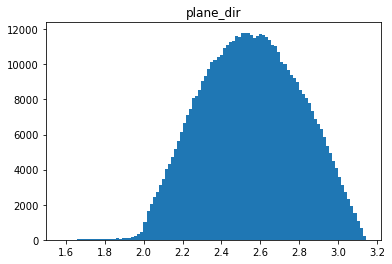

In [7]:
plt.title('plane_dir')
plt.hist(th,bins=100)

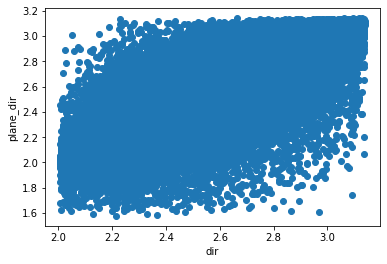

In [8]:
plt.xlabel('dir')
plt.ylabel('plane_dir')
plt.scatter(theta,th)

In [9]:
np.count_nonzero(th==np.pi)

0

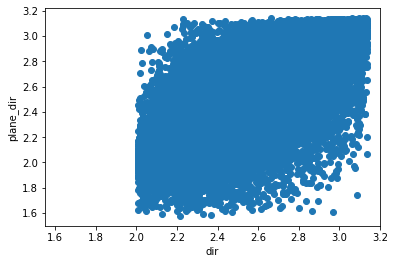

In [10]:
plt.xlim(1.55,3.2)
plt.xlabel('dir')
plt.ylabel('plane_dir')
plt.scatter(theta[th>np.pi/2],th[th>np.pi/2])

In [12]:
print(pd.DataFrame(np.nanmean(x[...,3],axis=0)))

             0            1            2            3            4  \
0     0.000000     0.000000     0.000000     0.000000  2707.249171   
1     0.000000     0.000000     0.000000  2951.520772  2999.748543   
2     0.000000     0.000000  2983.957849  3036.515374  3236.263215   
3     0.000000  2755.438628  3266.898065  3211.904281  3232.395091   
4  2594.965627  3006.568932  3413.281866  3747.833665  3233.485593   
5  2694.582355  3186.244067  3483.357224  3194.111696  3029.910673   
6  2786.846329  2925.232544  3038.393667  2967.675476  2850.907791   
7  2637.655650  2989.515915  3092.756841  3174.358417  2466.129320   
8  2530.340519  2807.663276  2833.677582  2378.395099  2445.726194   
9  2216.102584  2291.625999  2343.308055  2177.068202     0.000000   

             5            6            7            8            9  
0  3288.834237  3254.780845  3051.858332  3125.234494  2557.810023  
1  3437.177025  3815.590434  2979.512397  3284.230968  2507.497487  
2  3893.152825  3967.8

In [ ]:
print(pd.DataFrame(x[213,...,3]))
print(pd.DataFrame(x[213,...,2]))

In [ ]:
np.count_nonzero(th<np.pi/2)

In [ ]:
print(x.shape)
x1 = np.sum(x,axis = 3)
print(x1.shape)
x2 = np.sum(x1,axis = 2)
x3 = np.sum(x2,axis = 1)
print(x3.shape)

In [ ]:
np.count_nonzero(th<np.amin(theta))

In [ ]:
np.amin(theta)

In [ ]:
plt.hist(energy,bins=100)

In [ ]:
print(x[...,0].flatten().shape)
print('Proportion of stations with Q1 != 0:',np.count_nonzero(x[...,0],axis=0,keepdims=True)/54977300)
print('Proportion of stations with Q1 != 0:',np.count_nonzero(x[...,0])/54977300)
print('Proportion of stations with Q2 != 0:',np.count_nonzero(x[...,1])/54977300)
print('Proportion of stations with Q1 and Q2 = 0:',np.count_nonzero(np.logical_and(x[...,0] == 0.0,x[...,1] == 0.0))/54977300)
print('Proportion of energy != 0:',np.count_nonzero(energy)/549773)

In [ ]:
plt.hist(x[...,0].flatten(),bins=100)

In [ ]:
plt.hist(x[x[...,0]!=0.0,0].flatten(),bins=100)

In [ ]:
plt.hist(x[x[...,1]!=0.0,1].flatten(),bins=100)

In [ ]:
notBothZero = np.invert(np.logical_and(x[...,0] == 0.0,x[...,1] == 0.0))
plt.hist(x[notBothZero,1].flatten()-x[notBothZero,0].flatten(),bins=100)

## Model Training

### Alpha Model
- Input: no charge merge, no time layers included, normalized data
- Layers: Two convolutional
- Output: Energy

In [ ]:
# Name for model
key = 'first_model'

# Data preparation: no merging of charge (q), no time layers included (t=False), data normalized from 0-1
prep = {'q':None, 't':False, 'normed':True}

In [ ]:
# Create model
model = Sequential(name=nameModel(prep, 'test'))  # Automatic naming for flexible assessment later
# Add model layers
model.add(Conv2D(64, kernel_size=3, activation='relu', input_shape=(10,10,2)))
model.add(Conv2D(32, kernel_size=3, activation='relu'))
model.add(Flatten())
model.add(Dense(1)) # No activation function for last layer of regression model

# Compile model
model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae','mse'])

In [ ]:
# Establish arrays to be trained on
x_i = dataPrep(x, y, **prep)
temp_y = energy

In [ ]:
# Train
history = model.fit(x_i[trainCut], temp_y[trainCut], validation_data=(x_i[valCut], temp_y[valCut]), epochs=3)

In [ ]:
# Save model to file for easy loading
## WHERE ARE YOU SAVING TO?
model.save('model_%s.h5' % key)
model.evaluate(x_i[testCut], temp_y[testCut])

## Your task

- **Create your own model**
- Replace the model here w/ *simplified* form of Brandon's model (focus: including zenith)
- change the zenith input to cosine(zenith) input

In [ ]:
history.history